Loading the Data.
we read the csv containing the lables and the link to the public image repositiory hosted by the creators of the data.
The goal is to have all the images stored locally in the respective folders of the differnt classes of skin conditions, in this case 114 classes. The following procedures will be followed
1) Read the csv containing the image links and other attributes
2) Select images that correspond to the dark skin on fitzpartick scale, which are 4,5 and 6
3) Store them in separate folders according to the classes. 
4) Data Exploration to make the data most suitable for the tasks at hand

In [42]:
import pandas as pd
data_list = pd.read_csv("D:/Research/Datasets/fitzpatrick17k/fitzpatrick17k.csv")
data_list.describe()

,fitzpatrick_scale,fitzpatrick_centaur
count,16577.000000,16577.000000
mean,2.685709,2.255113
std,1.526522,1.658569
min,-1.000000,-1.000000
25%,2.000000,1.000000
50%,2.000000,2.000000
75%,4.000000,3.000000
max,6.000000,6.000000


In [44]:
#A Sneakpeak into the data list
data_list.head(10)

,md5hash,fitzpatrick_scale,fitzpatrick_centaur,label,nine_partition_label,three_partition_label,qc,url,url_alphanum
0,5e82a45bc5d78bd24ae9202d194423f8,3,3,drug induced pigmentary changes,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicmminoc...
1,fa2911a9b13b6f8af79cb700937cc14f,1,1,photodermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicpphoto...
2,d2bac3c9e4499032ca8e9b07c7d3bc40,2,3,dermatofibroma,benign dermal,benign,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicdderma...
3,0a94359e7eaacd7178e06b2823777789,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...
4,a39ec3b1f22c08a421fa20535e037bba,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...
5,45f7fe0e10214e32e890cad9d29d4811,6,5,kaposi sarcoma,malignant dermal,malignant,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpickkapos...
6,6c395be9325dbb10e55497304b398253,2,2,neutrophilic dermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicssweet...
7,9dc73230c77ab5c58dc1f11caef39ea2,2,1,granuloma annulare,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicggranu...
8,f23937e86de55c3471ac5d0143b67e08,4,4,nematode infection,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicLlarva...
9,09d46db9589ff45436cda87c4abc946b,3,2,allergic contact dermatitis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicaaller...


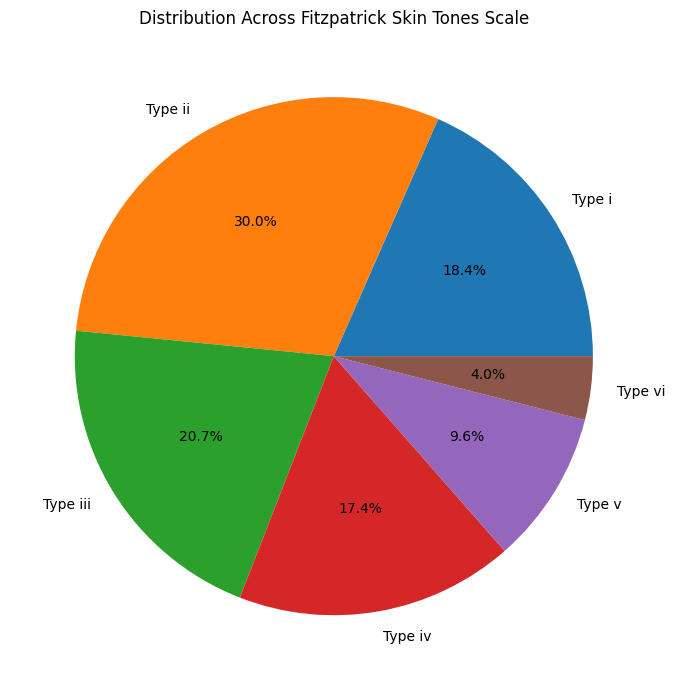

In [71]:
# Pie Chart showing Distibution of Cases based on Fitzpatick17k scale
import matplotlib.pyplot as plt
import numpy as np
scale_1, scale_2, scale_3, scale_4, scale_5, scale_6 = 0, 0, 0, 0, 0, 0
for scale in data_list["fitzpatrick_scale"]:
    if scale == 1:
        scale_1 += 1
    if scale == 2:
        scale_2 += 1
    if scale == 3:
        scale_3 += 1
    if scale == 4:
        scale_4 += 1
    if scale == 5:
        scale_5 += 1
    if scale == 6:
        scale_6 += 1


labels = ['Type i', 'Type ii', 'Type iii', 'Type iv', 'Type v', 'Type vi' ]
Sizes = np.array([scale_1, scale_2, scale_3, scale_4, scale_5, scale_6])
#plotiing

plt.figure(figsize = (7, 7))
plt.pie( Sizes, 
    labels=labels,
    autopct='%1.1f%%')

plt.title("Distribution Across Fitzpatrick Skin Tones Scale")
plt.tight_layout()
plt.show()

In [3]:
#Data corresponding to dark skin on fitzpatrick scale 4,5,6. The examples reduce from 16577 to 4934 
data_pigmented = data_list[data_list["fitzpatrick_scale"].isin([1, 2, 3, 4, 5 , 6]) & data_list["url"].notna()]

#remove duplicated urls
filtered_data_pigmented = data_pigmented.drop_duplicates(subset="url")
filtered_data_pigmented.describe()

,fitzpatrick_scale,fitzpatrick_centaur
count,15974.000000,15974.000000
mean,2.814699,2.306748
std,1.383410,1.614259
min,1.000000,-1.000000
25%,2.000000,1.000000
50%,3.000000,2.000000
75%,4.000000,3.000000
max,6.000000,6.000000


In [ ]:
# Create the storage folder for the images download
#import os
#image_directory = "D:/MSCS_Research/Datasets/datasets/RAW/all_skin_images"
#os.makedirs(image_directory, exist_ok = True)



In [85]:
# Paths
import os
#dataset_dir = "D:/MSCS_Research/Datasets/RAW/all_skin_images"   # contains class folders
dataset_dir ="D:/MSCS_Research/Datasets/RAW/sd-198/SD_198"


In [7]:
#@title Downloading and Resizing Images
from pathlib import Path
import requests
from io import BytesIO
from PIL import Image
# Target folder under My Drive


# Remove duplicates from the dataset
filtered_data = filtered_data_pigmented.drop_duplicates(subset=['url'])

# Headers to mimic a browser request
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,image/apng,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer": "https://www.google.com/",
    "Connection": "keep-alive"
}

# Initialize counters
total_images_downloaded = 0
failed_urls = []

# Download, resize, and save images
for idx, row in filtered_data_pigmented.iterrows():
    lbl, url = row['label'], row['url']
    outdir = os.path.join(dataset_dir, lbl)
    os.makedirs(outdir, exist_ok=True)
    try:
        # Use headers in the request
        resp = requests.get(url, headers=headers, timeout=10, verify=True)  # Add headers
        resp.raise_for_status()

        # Process and save the image
        img = Image.open(BytesIO(resp.content)).convert('RGB')
        img = img.resize((224, 224))

        # Ensure unique filenames
        unique_filename = f"{idx}_{hash(url)}.jpg"
        img.save(os.path.join(outdir, unique_filename))
        total_images_downloaded += 1
    except Exception as e:
        failed_urls.append((url, str(e)))  # Log failed URLs
        

# Verify and count total files
file_count = sum(1 for _ in Path(dataset_dir).rglob('*.jpg'))

# Display results
print(f"Total images downloaded and stored: {total_images_downloaded}")
print(f"Total image files found in folder and subfolders: {file_count}")
print(f"Failed URLs: {len(failed_urls)}")

# Save failed URLs for review
failed_urls_path = 'D:/MSCS_Research/Datasets/datasets/failed_urls.txt'
with open(failed_urls_path, 'w') as f:
    for url, error in failed_urls:
        f.write(f"{url}\t{error}\n")
print(f"Failed URLs logged to: {failed_urls_path}")



Total images downloaded and stored: 4126
Total image files found in folder and subfolders: 4126
Failed URLs: 11848
Failed URLs logged to: D:/MSCS_Research/Datasets/datasets/failed_urls.txt


In [38]:
import os
import glob
import shutil
import pandas as pd

# Paths
passion_url = r"D:/MSCS_Research/Datasets/RAW/PASSION_MICCAI_2024"
labels_path = os.path.join(passion_url, "label.csv")
images_dir = os.path.join(passion_url, "images")
out_root = os.path.join(passion_url, "passion2024")  # output dataset root

# Load labels
df = pd.read_csv(labels_path)

# TODO: confirm these column names match your CSV exactly
ID_COL = "subject_id"
LABEL_COL = "conditions_PASSION"

os.makedirs(out_root, exist_ok=True)

missing_subjects = []
copied = 0

for row in df.itertuples(index=False):
    subject_id = str(getattr(row, ID_COL))
    label = str(getattr(row, LABEL_COL))

    # Make label folder
    label_dir = os.path.join(out_root, label)
    os.makedirs(label_dir, exist_ok=True)

    # Find subject images: 123.jpg, 123_1.jpg, 123_2.jpg, ...
    pattern = os.path.join(images_dir, f"{subject_id}*.jpg")
    matches = sorted(glob.glob(pattern))

    if not matches:
        missing_subjects.append(subject_id)
        continue

    # Copy each image into the label folder
    for src_path in matches:
        fname = os.path.basename(src_path)

        # If a file with same name already exists, make it unique
        dst_path = os.path.join(label_dir, fname)
        if os.path.exists(dst_path):
            base, ext = os.path.splitext(fname)
            k = 1
            while True:
                alt_name = f"{base}__dup{k}{ext}"
                dst_path = os.path.join(label_dir, alt_name)
                if not os.path.exists(dst_path):
                    break
                k += 1

        shutil.copy2(src_path, dst_path)
        copied += 1

print(f"Done. Copied {copied} images into: {out_root}")
print(f"Subjects with no images found: {len(missing_subjects)}")
if missing_subjects:
    print("Example missing IDs:", missing_subjects[:20])

Done. Copied 4901 images into: D:/MSCS_Research/Datasets/RAW/PASSION_MICCAI_2024\passion2024
Subjects with no images found: 0


In [ ]:
from PIL import Image
classes = sorted(os.listdir(dataset_dir))
#classes = sorted(os.listdir(out_root))
data = []
cc = 0
corrupt_images = []
for c in classes:
    class_dir = os.path.join(dataset_dir, c)
    if not os.path.isdir(class_dir):
        continue
    for img_file in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_file)
        try:
            img = Image.open(img_path)
            w, h = img.size
            data.append((c, img_file, w, h))
        except:
            print("Corrupt image:", img_path)

df = pd.DataFrame(data, columns=["class", "filename", "width", "height"])
df.head()


C:\Users\Obete\AppData\Local\Temp\ipykernel_5460\113242838.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="class_id", y="count", data=class_counts, palette="viridis")


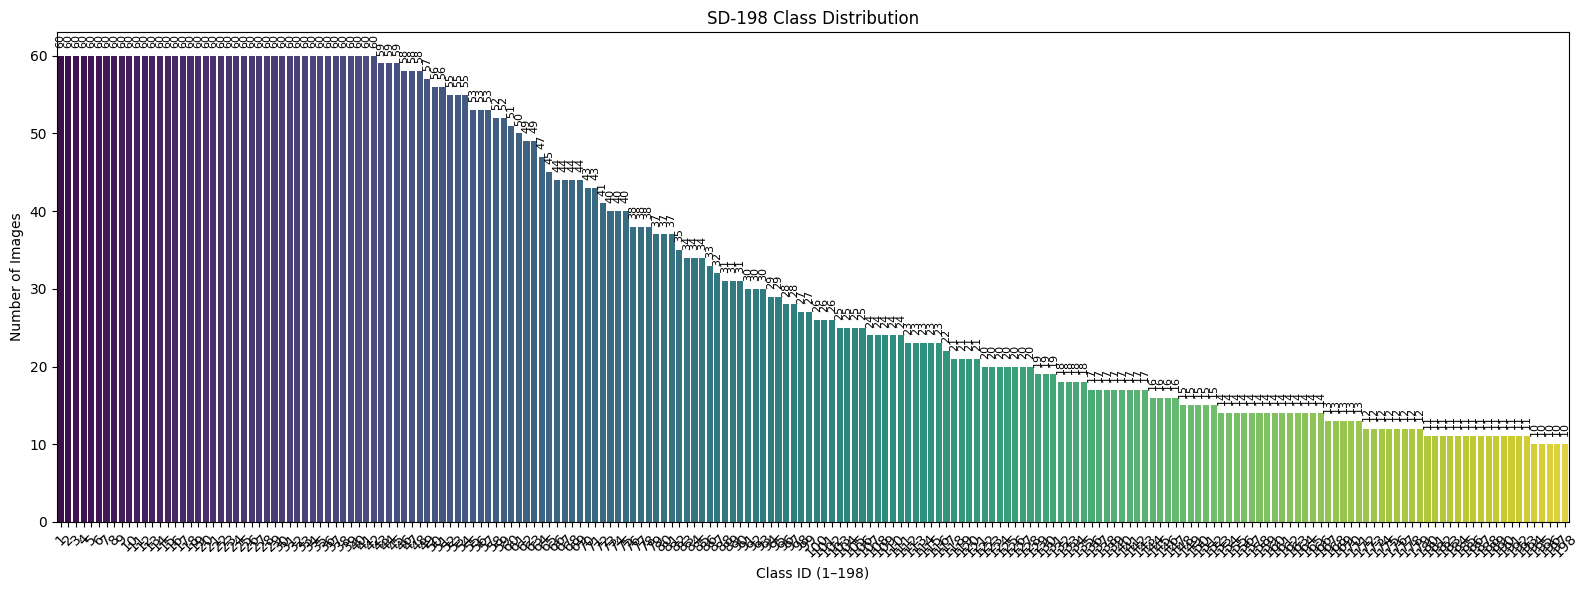

In [88]:
# Class distribution
import matplotlib.pyplot as plt
import seaborn as sns
# Counting images per class
class_counts = df["class"].value_counts().reset_index()
class_counts.columns = ["class", "count"]

# Creating numeric labels for classes ---
class_counts["class_id"] = range(1, len(class_counts) + 1)

# Merging numeric IDs back to df
id_map = dict(zip(class_counts["class"], class_counts["class_id"]))
df["class_id"] = df["class"].map(id_map)

# Ploting
plt.figure(figsize=(16, 6))
sns.barplot(x="class_id", y="count", data=class_counts, palette="viridis")

# Add counts on top of bars
for i, row in class_counts.iterrows():
    plt.text(row["class_id"] - 1, row["count"] + 1, str(row["count"]), 
             ha='center', va='bottom', fontsize=8, rotation=90)

plt.title("SD-198 Class Distribution")
plt.xlabel("Class ID (1–198)")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [41]:
#Tabular representation of the data
class_counts = df["class"].value_counts().reset_index()
class_counts.columns = ["class_name", "image_count"]

class_counts["class_id"] = range(1, len(class_counts) + 1)
class_summary = class_counts[["class_id", "class_name", "image_count"]].sort_values("class_id")

print("\n Dataset Summary:")
print(class_summary.to_string(index=False))
summary_csv = os.path.join(dataset_dir, "class_summary.csv")
class_summary.to_csv(summary_csv, index=False)
print(f"\n Summary table saved to: {summary_csv}")


 Dataset Summary:
 class_id class_name  image_count
        1     Eczema          105
        2    Scabies          102

 Summary table saved to: D:/MSCS_Research/Datasets/datasets/ALL_FITZPATRICK\class_summary.csv
